In [2]:
import matplotlib.pyplot as plt
import sys
sys.path.append('../../Codes/library/')

from funcs import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'
output_plot = '/Users/robertomorantovar/Dropbox/My_Documents/Science/Projects/Immune_System/_Repository/Figures/exponential_proofreading/antigen_presentation/'
os.makedirs(output_plot, exist_ok=True)

%autosave 60

Autosaving every 60 seconds


In [32]:
def simulate_exact(alpha, sigma, lam, delta, x0, T=None, Theta=None, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break

        # birth clock (NHPP)
        r = rng.exponential(1.0)
        tau_b = (1.0/lam) * np.log(1.0 + (lam/alpha**sigma)*r*np.exp(-lam*t))

        # death clock
        if n > 0:
            tau_d = rng.exponential(1.0/(delta*n))
        else:
            tau_d = np.inf

        if tau_b < tau_d:
            t += tau_b
            n += 1
        else:
            t += tau_d
            n -= 1

        traj.append((t, n))

    return traj  # also return division time if Theta used

In [4]:
def simulate_tauleap(alpha, lam, delta, x0, T=None, Theta=None,
                     eps=0.05, eta=0.2, dt_max=np.inf, rng=np.random):
    t = 0.0
    n = x0
    traj = [(t, n)]
    while True:
        if T is not None and t >= T: break
        if Theta is not None and n >= Theta: break

        dt1 = (1.0/lam) * np.log(1.0 + eps)         # control exp-growth change
        dt2 = eta / delta                            # control death fraction
        dt  = min(dt1, dt2, dt_max)

        # don't step past the end time
        if T is not None:
            dt = min(dt, T - t)
            if dt <= 0: break

        # births: Poisson with integrated intensity
        m_b = (alpha/lam) * (np.exp(lam*(t+dt)) - np.exp(lam*t))
        B = rng.poisson(m_b)

        # deaths: Binomial (nonnegative guarantee)
        p = 1.0 - np.exp(-delta*dt)
        D = rng.binomial(n, p) if n > 0 else 0

        n = n + B - D
        t = t + dt
        traj.append((t, n))

    return traj

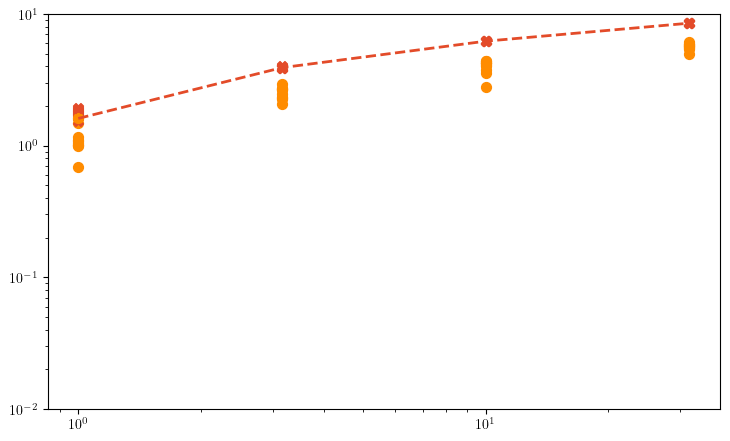

In [48]:
# fig_traj, ax_traj = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
fig, ax = plt.subplots(figsize=(5*1.62,5), gridspec_kw={'left':0.12, 'right':.95, 'bottom':.15, 'top': 0.94})
theta = 5.
beta = 2.5
sigma = 2.0
times = np.linspace(10, 20, 100)
Ks = np.logspace(0, 1.5, 4)
ts_act_min = []
for i_ens in range(10):
    for K, omega in zip(Ks, Ks**beta):
        # ax.scatter(Ks, omega, color = my_blue, label = r'$\alpha=%.2e$' % (1/Ks))
        ts_act = []
        for n in range(int(10*omega)):
            traj1 = simulate_exact(alpha=1/K, sigma = sigma, lam=1, delta=0.1, x0=0, T=20, Theta=theta)
            ts_act.append(traj1[-1][0])
            # traj2 = simulate_tauleap(alpha=alpha, lam=1, delta=0.01, x0=0, T=20, Theta=theta)
            # ax_traj.step(*zip(*traj1), color = my_blue)
            # ax_traj.step(*zip(*traj2), color = my_green)
        ts_act_min.append(np.min(ts_act))
        plt.scatter(K, np.min(ts_act), color = 'darkorange', label = r'$\K=%.2e$' % (1/K), s = 50)
        plt.scatter(K, np.mean(ts_act), color = my_red, label = r'$\K=%.2e$' % (1/K), s = 50, marker='X')
        # plt.errorbar(Ks, np.mean(ts_act), 2*np.std(ts_act), color = my_red, alpha = 0.5)
# ax.plot(Ks, ts_act_min, color = my_red, ls = '--', lw = 2, label = r'$\min(t_{act})$')
# ax_traj.plot(times, np.exp(times - 10), color = my_red, ls = '--', lw = 2, label = r'$\Theta$')
# ax_traj.hlines(theta, 0, 20, color = my_red, ls = '--', lw = 2)

ax.plot(Ks, sigma*np.log(Ks) + np.log(theta), color = my_red, ls = '--', lw = 2, label = r'$\log(K)$')

# my_plot_layout(ax=ax, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
# ax_traj.set_yscale('log')
# ax_traj.set_ylim(bottom=0.8, top = 1.5*theta)
# ax.legend()

# my_plot_layout(ax=ax, ticks_labelsize= 40, x_fontsize=30, y_fontsize=30)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-2, top = 1e1)
# ax.legend()
fig.savefig(output_plot + 'times_sigma-%.2f_theta-%.2f.pdf' % (sigma, theta))